In [11]:
import sys
print(sys.executable)

import astropy.units as u
from astropy.units import imperial
import numpy as np
import matplotlib.pyplot as plt

import os
import re
from pathlib import Path
import astropy.units as u
from astropy.units import imperial

/opt/miniconda3/envs/conda/bin/python


Load in CSV files of frames and ensure they are sorted by frame number.

In [ ]:
# Specify directory where CSV files are stored
datadir = "2026-03-11"
# Naming convention assumes shot number is part of directory path
shotnum = 1002187
# Create empty dictionary to hold images by frame number
images = {}
for file in os.listdir(os.path.join(Path.cwd(),'data',datadir, str(shotnum))):
    # Search directory for all CSV files
    if file.endswith(".csv"):
        # Regular expression search for frame number from file name
        frame = re.search(r"(\d+).csv",file)
        # Add dictionary entry with frame number as key
        images[int(frame.group(1))] = np.genfromtxt(os.path.join(Path.cwd(),'data', datadir, str(shotnum), file),delimiter=',')
# Sort dictionary by keys (frames) and create numpy array
sorted_imgs = np.array([images[k] for k in sorted(images)])

# Create array of Delta_T for heat flux calculation
diff_arr = np.gradient(sorted_imgs,20e-3,axis=0) # 20ms between frames


Want to solve for a 1D heat conduction equation:
$$
q_{ss} = c_p \rho x \frac{\Delta T}{\Delta t}
$$
Using values for heat capacity and density of 304 SS found at: https://www.osti.gov/servlets/purl/4152287

In [ ]:
# specific heat of 304 SS
# c = 530 * u.J/(u.kg*u.K) # J/kg*K
c = 0.125 * imperial.cal/(u.g*u.K)  # cal/g*K

# density of 304 SS
rho = 7894 * u.kg/(u.m**3)  # kg/m^3

# thickness of target plate
x = (0.06)*0.0254 * u.m  # m

t = np.arange(diff_arr.shape[0]) * 20e-3

t1 = 54
t2 = 70
index = 120

dt = (t[t2] - t[t1]) * u.s

dT = 60.9 * u.K

qss = (rho * x * c * (diff_arr * u.K/u.s)).to(u.MW / (u.m**2))

q0 = rho * x * c * (dT / (0.5 * u.s))

print(q0.to(u.MW / (u.m**2)))

roi_q = np.mean(np.mean(qss[:,150:200,350:400], axis=-1), axis=-1)

print(np.trapz(roi_q[t1:t2], dx=20e-3))

print((np.trapz(roi_q[t1:t2], dx=20e-3)) * u.s / dt)

0.7663568898384 MW / m2
0.04582036674283148 MW / m2
0.14318864607134835 MW / m2


Delta T = 0.32000000000000006


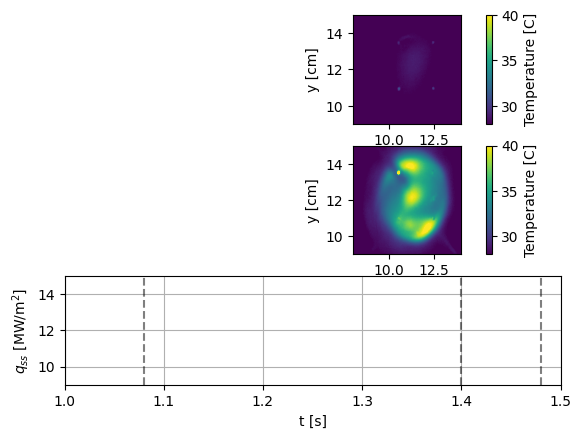

In [10]:
fig,ax = plt.subplots(3)

# Pixels per m found using centroid detection on through holes in image, these are the values found
px = 63/0.0254 # pixels per m
nx = sorted_imgs.shape[1]
x = (np.arange(nx)/px)*100
py = 63/0.0254 # pixels per m
ny = sorted_imgs.shape[1]
y = (np.arange(ny)/py)*100
t = np.arange(diff_arr.shape[0])*20e-3
t1 = 54
t2 = 70
index = 120
im = ax[0].imshow(sorted_imgs[t1,:,:],vmin=28,vmax=40,extent=[x[0],x[-1],y[0],y[-1]])
im2 = ax[1].imshow(sorted_imgs[t2,:,:],vmin=28,vmax=40,extent=[x[0],x[-1],y[0],y[-1]])
for axes in ax:
    axes.set_xlim(8,14)
    axes.set_ylim(9,15)
    axes.set_ylabel('y [cm]')
    axes.set_xlabel('x [cm]')
ax[-1].plot(t,np.mean(np.mean(qss[:,150:200,350:400],axis=-1),axis=-1))
ax[-1].axvline(t[t1],linestyle='dashed',color='black',alpha=0.5)
ax[-1].axvline(t[t2],linestyle='dashed',color='black',alpha=0.5)
ax[-1].axvline(t[t1]+0.4,linestyle='dashed',color='black',alpha=0.5)
ax[-1].set_ylabel("$q_{ss}$ [MW/m$^2$]")
ax[-1].set_xlabel("t [s]")
ax[-1].grid()
print(f"Delta T = {t[t2]-t[t1]}")
fig.colorbar(im,label='Temperature [C]')
fig.colorbar(im2,label='Temperature [C]')
ax[-1].set_xlim(1,1.5)
plt.show()